# **Step2. Multi-label 분류**



**미션 : 리뷰에 포함된 11가지 속성을 검출하기(Multi-label Multi-Classification)**

1) 목표 : 리뷰 내용에서, 속성에 해당하는 내용이 등장하는지 분류하는
모델 생성
2) 절차
    * 데이터 전처리 : 주어진 데이터를 목표에 맞는 형태로 변환
    * 모델링 : 다중 레이블 분류 파인 튜닝
        * 일반 파인 튜닝
        * LoRA 파인 튜닝

## 1.환경준비

### (1) 라이브러리 설치 및 로딩

In [ ]:
!pip install datasets peft accelerate -q

In [ ]:
# 한글폰트 설치
import matplotlib as mpl
import matplotlib.font_manager as fm

%config InlineBackend.figure_format = 'retina'
!apt -qq -y install fonts-nanum

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import torch

from transformers import Trainer, TrainingArguments, EarlyStoppingCallback, AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder

from peft import get_peft_model, LoraConfig, TaskType

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

c:\Users\USER\anaconda3\envs\aivle_pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# (Jupyter) 시각화 한글폰트 설정을 위해 아래 코드를 실행하세요.
plt.rc('font', family='Malgun Gothic')
sns.set(font="Malgun Gothic",#"NanumGothicCoding",
        rc={"axes.unicode_minus":False}, # 마이너스 부호 깨짐 현상 해결
        style='darkgrid')

### (2) GPU 설정
* GPU 사용을 위한 설정

In [3]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2.데이터 준비

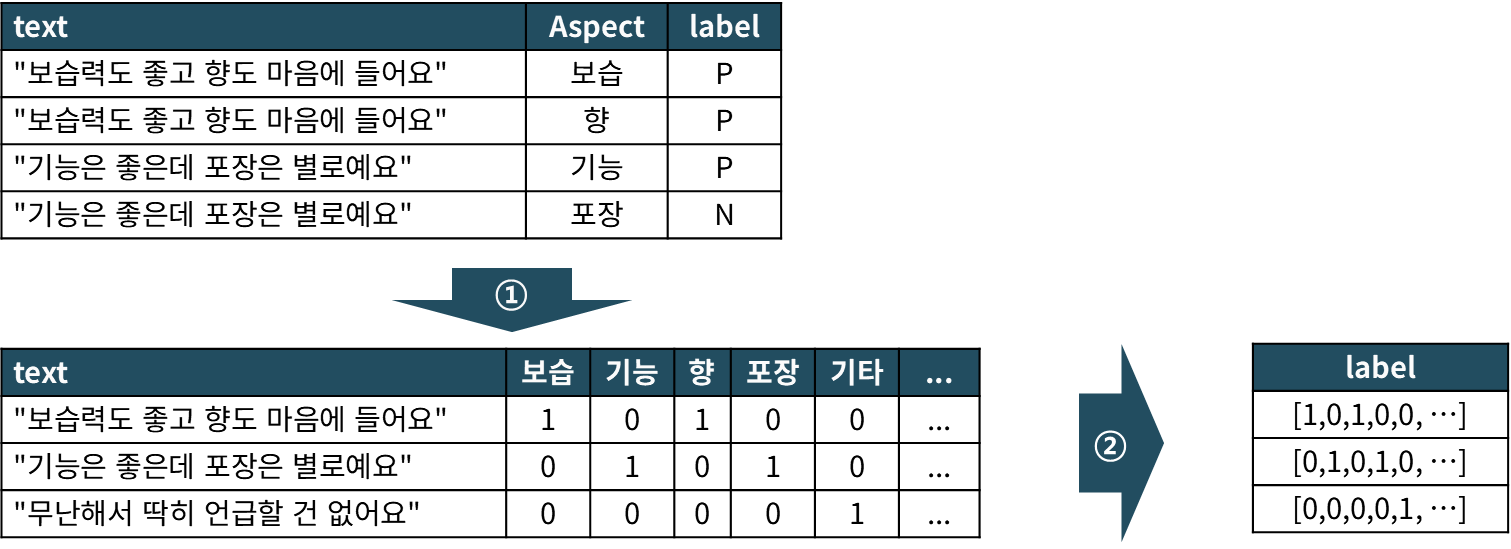

### (1) 데이터 로딩
* data.csv 파일 로딩

In [ ]:
# 파일 업로드
from google.colab import files
uploaded = files.upload()

In [4]:
path = './data/'
df = pd.read_csv(path + 'data.csv')

### (2) Dataset 준비1

In [5]:
# 레이블 리스트
labels = ['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']

* multi-hot label 만들기
    * multi-hot label 값이 문자열이 아닌 리스트여야 합니다.
* multi-hot label을 추가한 데이터셋을 data1 으로 저장합니다.

In [6]:
df_drop = df.drop(columns=['label'])

In [7]:
from sklearn.preprocessing import MultiLabelBinarizer

df_grouped = df.groupby('text')['aspect'].apply(list).reset_index()
df_grouped

,text,aspect
0,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,"[보습, 품질, 포장, 포장, 피부, 기타, 밀착]"
1,'2022 대한민국소비자대상' 수상을 축하하며 오랜만에 써 본 OO OOO 로션 사...,"[보습, 피부, 편의성, 피부]"
2,'OO OOO 쿠션 파운데이션' 이 제품 이름을 보고 너무 궁금해서 구입했어요. 얼...,"[밀착, 보습, 포장, 보습, 외형]"
3,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,"[밀착, 품질, 기타, 편의성, 향]"
4,* 향기도 너무 마음에 들고 발라보니 촉촉하고 부드럽고 매끄러워 피부가 좋아지는 것...,"[보습, 향]"
...,...,...
39490,힘없고 탄력 없는 숱도 없는 머리입니다. 일반 샴푸 쓰면 두피가 가렵거나 뾰루지가 ...,"[피부, 보습]"
39491,힘이 생겨 그런지 볼륨은 덜 살지만 윤기가 좀 도는것 같고 모발이 좀 더 굵어진 느...,[기능]
39492,힘줘서 바른것도 아니고 11월 말일인 이 계절에 한번 쓰윽 발랐더니 스틱이 으깨지네...,"[가격, 포장, 기타, 향]"
39493,２１호를 샀는데 너무 색깔이 밝아서 이상해요.23호사야 됐었을까 생각하게 되네요. ...,[외형]


In [8]:
mlb = MultiLabelBinarizer(classes=labels)
multi_hot = pd.DataFrame(mlb.fit_transform(df_grouped['aspect']), columns=mlb.classes_)
multi_hot.head(1)

,보습,기능,밀착,가격,향,편의성,기타,외형,포장,품질,피부
0,1,0,1,0,0,0,1,0,1,1,1


In [9]:
df_encoded = pd.concat([df_grouped['text'], multi_hot], axis=1)
df_encoded.head(1)

,text,보습,기능,밀착,가격,향,편의성,기타,외형,포장,품질,피부
0,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,1,0,1,0,0,0,1,0,1,1,1


* 검증 : 제대로 생성되었는지 다음 코드로 검증해 봅니다.

In [10]:
review = "(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점)"
display(df_encoded[df_encoded['text'].str.startswith(review)])
display(df[df['text'].str.startswith(review)])

,text,보습,기능,밀착,가격,향,편의성,기타,외형,포장,품질,피부
3,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,0,0,1,0,1,1,1,0,0,1,0


,text,aspect,label
42656,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,밀착,1
42657,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,품질,0
42658,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,기타,1
42659,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,편의성,1
42660,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,향,1


* 전체 데이터에서 10000건을 샘플링 합니다.(파인튜닝 시간 절약을 위해서)

In [11]:
# 데이터 샘플링
size = 10000
df_10k = df_encoded[:size]

### (3) Dataset 준비2
* train, val 분할 7:3
* 텐서 데이터셋

In [14]:
# train, val 분할 7:3
from sklearn.model_selection import train_test_split

train, val = train_test_split(df_10k, test_size=0.3, random_state=42)

In [15]:
# df로 부터 텐서 데이터셋 만들기
train_ts = Dataset.from_pandas(train) 
val_ts = Dataset.from_pandas(val)

In [16]:
train_ts[:3]

{'text': ['도착하자마자 바로 사용했어요. 투명해지는데는 좀 오래 걸려요. 시원하고 피부가 쫀쫀해지는 느낌은 좋습니다. 선호하는 향은 아니지만 1일1 팩할 듯합니다. 가격은 더 저렴해지면 좋을 것 같아요.',
  '가격 저렴하고 집에서 혼자 하기 좋습니다. 미용실 2주마다 가야 되는데 집에서 편하게 할 수 있어 좋네요. 근데 냄새 좀 심하고 베개에도 냄새가 나요.',
  '눈밑에 잔주름이 바르고나며3분이내 팽팽해져서 눈밑에주름있는지표시가안나서 기분이 넘좋았어요 목주름도마찬가지예요~짱!이예요'],
 '보습': [1, 0, 0],
 '기능': [1, 0, 1],
 '밀착': [0, 0, 0],
 '가격': [1, 1, 0],
 '향': [1, 1, 0],
 '편의성': [0, 1, 0],
 '기타': [0, 0, 0],
 '외형': [0, 0, 0],
 '포장': [0, 0, 0],
 '품질': [0, 0, 0],
 '피부': [0, 0, 0],
 '__index_level_0__': [9069, 2603, 7738]}

### (4) 토크나이징

* 다중 레이블 분류 문제에서 label은 float 타입이어야 함

In [17]:
# 토크나이저 다운로드
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [18]:
# 전처리 함수 정의 : label을 float 타입으로 변환 포함
def preprocess_function(data):
    encodings = tokenizer(data['text'], truncation=True, padding=True, max_length=128)
    encodings['labels'] = [[float(data[col][i]) for col in labels] for i in range(len(data['text']))]
    
    return encodings

# 전처리 적용
train_ts = train_ts.map(preprocess_function, batched=True)
val_ts = val_ts.map(preprocess_function, batched=True)

Map: 100%|██████████| 3000/3000 [00:00<00:00, 11450.46 examples/s]


## 3.Fine-Tuning1
* 일반 파인 튜닝으로

### (1) 사전학습 모델 준비
* problem_type="multi_label_classification"

In [19]:
# label(클래스) 수 지정
n = len(labels)

# 모델 준비 : 옵션 problem_type="multi_label_classification" 추가
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels = n,
    problem_type="multi_label_classification"
).to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### (2) 학습 설정

* TrainArguments

In [20]:
training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-5,               # 작은 학습률
    per_device_train_batch_size = 32,   # 학습 배치 사이즈
    per_device_eval_batch_size = 32,
    num_train_epochs = 5,               # 에폭 수
    weight_decay = 0.02,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요
    logging_dir ='./logs',
    logging_steps = 10,
    report_to=None,
    fp16=True
)

* Trainer

In [22]:
# 학습 시 추가 함수 준비
from torch.utils.data import DataLoader
from transformers import default_data_collator

# 평가함수(선택 사항)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    preds = (probs > 0.5).astype(int)
    return {
        "weighted_f1": f1_score(labels, preds, average="weighted"),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

# 사용자 정의 data_collator(필수 사항)
def float_label_collator(features):
    batch = default_data_collator(features)
    batch["labels"] = batch["labels"].float()
    return batch

In [23]:
# Trainer 설정 :
trainer = Trainer(
    model=model,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    data_collator=float_label_collator,  # 필수사항
    compute_metrics=compute_metrics,     # 선택사항
)

C:\Users\USER\AppData\Local\Temp\ipykernel_15064\245137270.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


### (3) 학습
* 7000건 학습데이터에 대해서, 학습 시간이 10~13분 정도 소요 됩니다.

In [24]:
trainer.train()

Epoch,Training Loss,Validation Loss,Weighted F1,Macro F1
1,0.535500,0.525413,0.080141,0.058064
2,0.489500,0.485618,0.213999,0.157202
3,0.462300,0.460918,0.320589,0.263294
4,0.459300,0.445551,0.392730,0.337702
5,0.438300,0.438924,0.401321,0.348607


TrainOutput(global_step=1095, training_loss=0.48319773521597525, metrics={'train_runtime': 83.8423, 'train_samples_per_second': 417.45, 'train_steps_per_second': 13.06, 'total_flos': 1159275774720000.0, 'train_loss': 0.48319773521597525, 'epoch': 5.0})

### (4) 모델 검증평가

Evaluation results: {'eval_loss': 0.43111222982406616, 'eval_weighted_f1': 0.42904120772877874, 'eval_macro_f1': 0.3814921714790385, 'eval_runtime': 1.997, 'eval_samples_per_second': 1502.258, 'eval_steps_per_second': 47.071, 'epoch': 5.0}


* 예측값

In [25]:
pred_output = trainer.predict(val_ts)

In [33]:
logits = pred_output.predictions 
labels = pred_output.label_ids 

probs = 1 / (1 + np.exp(-logits))
preds = (probs > 0.5).astype(int)

index = 0
display(val_ts[index]['text'])
preds[index]

'끈적이지 않아서 좋은 것 같아요. 다른 제품은 바르고 나서 끈적여서 싫었습니다. 피부가 촉촉해서 좋네요.'

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

* 실제값

In [34]:
labels[index]

array([1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

* 평가

In [37]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    labels,   
    preds,    
    average=None,
    zero_division=0
)

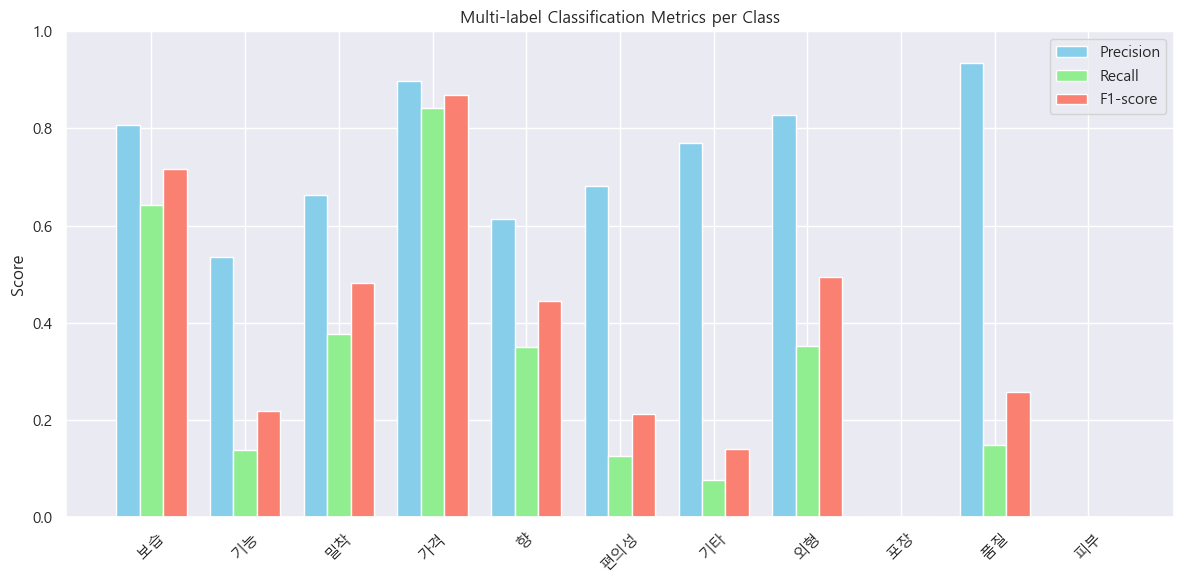

In [50]:
x = np.arange(len(labels_list))
width = 0.25

plt.figure(figsize=(12,6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width, label='F1-score', color='salmon')

plt.xticks(x, labels_list, rotation=45)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Multi-label Classification Metrics per Class')
plt.legend()
plt.tight_layout()
plt.show()


## 4.Fine-Tuning2
* LoRA 튜닝하기

### (1) 사전학습 모델 준비
* problem_type="multi_label_classification"

In [70]:
model_name = "distilbert-base-uncased"

# label(클래스) 수 지정
n = len(labels)

# 모델 준비 : 옵션 problem_type="multi_label_classification" 추가
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels = n,
    problem_type="multi_label_classification"
).to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### (2) LoRA 구성

In [71]:
# LoRA 구성 정의
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # 시퀀스 분류
    r=8,                         # 랭크 값 (작을수록 파라미터 적음)
    lora_alpha=32,               # 너무 작으면 학습 효과 약하고, 너무 크면 발산 위험
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"],  # DistilBERT에서 사용되는 attention 레이어 이름
    bias="none"                 # bias는 학습하지 않음
)

# LoRA 적용
model = get_peft_model(model, lora_config)

### (3) 학습 설정

* TrainArguments
    * 일반 파인 튜닝보다는 학습률을 조금 높게 설정

In [73]:
training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-4,        
    per_device_train_batch_size = 8,   # 학습 배치 사이즈
    per_device_eval_batch_size = 16,
    num_train_epochs = 10,               # 에폭 수
    weight_decay = 0.02,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요
    logging_dir ='./logs',
    logging_steps = 10,
    report_to=None,
    fp16=True
)

* Trainer

In [74]:
# 사용자 정의 data_collator 생
from torch.utils.data import DataLoader
from transformers import default_data_collator

def float_label_collator(features):
    batch = default_data_collator(features)
    batch["labels"] = batch["labels"].float()
    return batch

In [75]:
# Trainer 설정
trainer = Trainer(
    model=model,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    data_collator=float_label_collator
)

C:\Users\USER\AppData\Local\Temp\ipykernel_19700\3448237408.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


### (4) 학습

In [76]:
# 학습 시작
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.538800,0.534465
2,0.489400,0.486232
3,0.451300,0.464161
4,0.455400,0.444389
5,0.433200,0.419462
6,0.409900,0.405211
7,0.354900,0.396738
8,0.409800,0.389339
9,0.362100,0.386807
10,0.383900,0.384293


TrainOutput(global_step=8750, training_loss=0.4397672012056623, metrics={'train_runtime': 275.7635, 'train_samples_per_second': 253.841, 'train_steps_per_second': 31.73, 'total_flos': 2358683765760000.0, 'train_loss': 0.4397672012056623, 'epoch': 10.0})

In [78]:
eval_results = trainer.evaluate()
print(f"Evaluation results: {eval_results}")

Evaluation results: {'eval_loss': 0.3842929005622864, 'eval_runtime': 2.42, 'eval_samples_per_second': 1239.671, 'eval_steps_per_second': 77.686, 'epoch': 10.0}


### (5) 모델 검증평가

In [82]:
def predict(text, model, tokenizer):
    # 모델을 CPU로 이동
    model = model.to("cpu")

    # 입력 문장 토크나이징 → CPU 텐서로 생성
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    # 모델 예측 (no_grad로 메모리 절약)
    with torch.no_grad():
        outputs = model(**inputs)

    # 확률 계산
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=1)

    # 예측 클래스
    pred = torch.argmax(probabilities, dim=-1).item()

    return pred, probabilities


In [84]:
text = "IT기업 카카오"
predicted_class, probabilities = predict(text, model, tokenizer)

print(f"예측된 클래스: {predicted_class}")
print(f"예측된 클래스 이름: {labels[predicted_class]}")
print(f"클래스별 확률: {probabilities}")

예측된 클래스: 7
예측된 클래스 이름: 외형
클래스별 확률: tensor([[0.0241, 0.0252, 0.0441, 0.0174, 0.0018, 0.0362, 0.0100, 0.7467, 0.0788,
         0.0134, 0.0024]])


In [ ]:
predictions_output = trainer.predict(val_ts)
logits = predictions_output.predictions

# logits가 torch.Tensor인 경우 CPU로 옮기기
if isinstance(logits, torch.Tensor):
    logits = logits.detach().cpu().numpy()

pred = np.argmax(logits, axis=1)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix(val_ts['label'], pred), display_labels = label_list)
disp.plot()
plt.show()

print(classification_report(val_ts['label'], pred, target_names = label_list))